## CELL 1 — Imports & Colormap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

THERMAL_COLORS = ["#6A0DAD", "#0000FF", "#00CC00", "#FFFF00", "#FF8000", "#FF0000"]
COLOR_LABELS   = [
    "Violet  (Cold / Rest)",
    "Blue    (very low activity)",
    "Green   (moderate activity)",
    "Yellow  (elevated / fault entry zone)",
    "Orange  (active fault — lower severity)",
    "Red     (active fault — peak severity)"
]

cmap_thermal = ListedColormap(THERMAL_COLORS)
bounds       = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm         = BoundaryNorm(bounds, cmap_thermal.N)
HEIGHT       = 30

REST_VALUE     = 120.0    # idle level for both I1 and V1
REST_TOL       = 0.5      # tolerance: within +-0.5 of 120 = at rest
FAULT_COOLDOWN = 50       # steps below 2x normal needed to exit fault state

print("Setup complete.")

Setup complete.


## CELL 2 — Load Dataset (simOut, V1, I1 only)

In [ ]:
FILE_PATH = "/content/LLG_1_5_99.xlsx"

def load_signal_file(path):
    """
    Auto-detects file format and loads it correctly.
    Handles: .xlsx, old .xls, CSV/TSV saved with wrong extension,
    and comma/semicolon/tab delimiters.
    """
    import os
    ext = os.path.splitext(path)[1].lower()

    # Try 1: Standard xlsx (openpyxl engine)
    try:
        df = pd.read_excel(path, engine="openpyxl")
        print(f"Loaded as xlsx (openpyxl): {df.shape}")
        return df
    except Exception as e1:
        print(f"openpyxl failed: {e1}")

    # Try 2: Old .xls format (xlrd engine)
    try:
        df = pd.read_excel(path, engine="xlrd")
        print(f"Loaded as xls (xlrd): {df.shape}")
        return df
    except Exception as e2:
        print(f"xlrd failed: {e2}")

    # Try 3: CSV with comma delimiter
    try:
        df = pd.read_csv(path, sep=",")
        print(f"Loaded as CSV (comma): {df.shape}")
        return df
    except Exception as e3:
        print(f"CSV comma failed: {e3}")

    # Try 4: CSV with semicolon delimiter
    try:
        df = pd.read_csv(path, sep=";")
        print(f"Loaded as CSV (semicolon): {df.shape}")
        return df
    except Exception as e4:
        print(f"CSV semicolon failed: {e4}")

    # Try 5: Tab-separated
    try:
        df = pd.read_csv(path, sep="\t")
        print(f"Loaded as TSV (tab): {df.shape}")
        return df
    except Exception as e5:
        print(f"TSV failed: {e5}")

    raise ValueError(f"Could not load {path} with any known format. Check the file.")


# ── Install xlrd if not present (needed for old .xls files) ─────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "xlrd", "-q"])

df = load_signal_file(FILE_PATH)
df.columns = [c.strip() for c in df.columns]

print("\nColumns found:", df.columns.tolist())

# ── Extract the three required columns ──────────────────────────────────────
df = df[["simOut", "V1", "I1"]].copy()
df.columns = ["time", "voltage", "current"]
df = df.dropna().reset_index(drop=True)

time    = df["time"].values.astype(float)
voltage = df["voltage"].values.astype(float)
current = df["current"].values.astype(float)

print(f"{'Samples':<30}: {len(time)}")
print(f"{'Duration':<30}: {round(time[-1]-time[0], 6)} sec")
print(f"{'Current  min / max':<30}: {round(current.min(),3)} / {round(current.max(),3)} A")
print(f"{'Voltage  min / max':<30}: {round(voltage.min(),3)} / {round(voltage.max(),3)} V")

Loaded as xlsx (openpyxl): (24008, 42)

Columns found: ['simOut', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'Vq1', 'Vq2', 'Vq3', 'Vq4', 'Vq5', 'Vq6', 'Vq7', 'Vq8', 'Vq9', 'Vq1_err', 'Vq2_err', 'Vq3_err', 'Vq4_err', 'Vq5_err', 'Vq6_err', 'Vq7_err', 'Vq8_err', 'Vq9_err']
Samples                       : 24001
Duration                      : 1.19965 sec
Current  min / max            : 120.0 / 2332.726 A
Voltage  min / max            : 0.632 / 120.0 V


## CELL 3 — Baselines, Thresholds & ROC Arrays

In [ ]:
dt     = np.diff(time)
t_axis = time[1:]

# REST MASK (aligned to N-1 diff array)
rest_mask = (
    (np.abs(current[1:] - REST_VALUE) < REST_TOL) &
    (np.abs(voltage[1:] - REST_VALUE) < REST_TOL)
)

# CURRENT BASELINE: median of lower half of active (non-rest) samples
# Keeps normal_I in the pre-fault range even if dataset is fault-heavy
active_I   = np.abs(current[1:][~rest_mask])
low_thresh = np.percentile(active_I, 50)
normal_I   = float(np.median(active_I[active_I <= low_thresh])) if len(active_I) > 0 else REST_VALUE

thr_2x  = normal_I * 2.0
thr_5x  = normal_I * 5.0    # fault zone entry threshold
thr_10x = normal_I * 10.0

# Fault ceiling: 99th percentile of current to avoid single-spike distortion
fault_ceiling = float(np.percentile(np.abs(current), 99.9))

# VOLTAGE NOMINAL (full array)
v_nominal = float(np.max(np.abs(voltage)))

# ROC arrays: |signal(t) - signal(t-1)| / (t - t-1)
roc_I = np.abs(np.diff(current)) / (dt + 1e-12)
roc_V = np.abs(np.diff(voltage)) / (dt + 1e-12)
roc_I = np.nan_to_num(roc_I, nan=0.0, posinf=0.0, neginf=0.0)
roc_V = np.nan_to_num(roc_V, nan=0.0, posinf=0.0, neginf=0.0)

print(f"{'normal_I (active baseline)':<35}: {round(normal_I,3)} A")
print(f"{'Fault entry  > 5x':<35}: {round(thr_5x,3)} A")
print(f"{'Fault exit   < 2x for N steps':<35}: {round(thr_2x,3)} A")
print(f"{'Fault ceiling (p99.9)':<35}: {round(fault_ceiling,3)} A")
print(f"{'Max current in signal':<35}: {round(current.max(),2)} A")
print(f"{'v_nominal (max of V1)':<35}: {round(v_nominal,3)} V")

normal_I (active baseline)         : 304.795 A
Fault entry  > 5x                  : 1523.975 A
Fault exit   < 2x for N steps      : 609.59 A
Fault ceiling (p99.9)              : 2327.832 A
Max current in signal              : 2332.73 A
v_nominal (max of V1)              : 120.0 V


## CELL 4 — Color Mapping Functions

### ROC -> color (shared by both I and V)
Maps |Δsignal/Δt| to 6-level color index.

### Fault-gradient color (current only, within fault zone)
Within the fault zone, color is determined by where the current sits
in the range [thr_5x → fault_ceiling]:
- Bottom of fault range (just above 5x) → Yellow (3)
- Middle of fault range → Orange (4)
- Top of fault range (at peak) → Red (5)

This produces a smooth Yellow→Orange→Red gradient through the fault,
instead of locking everything to Red.

### Pre-fault level color (normal zone only)
Used only when NOT in fault zone — maps current to Blue/Green/Yellow
based on multiples of normal_I.

In [ ]:
def roc_to_color(r):
    """ROC value (A/s or V/s) -> color index 0-5."""
    if   r == 0:          return 0
    elif r <= 1_000:      return 1
    elif r <= 10_000:     return 2
    elif r <= 100_000:    return 3
    elif r <= 1_000_000:  return 4
    else:                 return 5


def fault_gradient_color(I_abs):
    """
    Within fault zone (I > thr_5x): map current magnitude to
    Yellow(3) -> Orange(4) -> Red(5) based on normalized position
    in [thr_5x, fault_ceiling].

    This gives a smooth gradient:
      - Just above fault entry threshold -> Yellow
      - Mid-fault level                  -> Orange
      - Peak fault current               -> Red
    """
    fault_range = max(fault_ceiling - thr_5x, 1.0)
    norm  = float(np.clip((I_abs - thr_5x) / fault_range, 0.0, 1.0))
    raw   = 3.0 + norm * 3.0     # 0.0 -> 3 (Yellow), 0.5 -> 4.5, 1.0 -> 6 (clipped to 5)
    return int(np.clip(int(raw), 3, 5))


def prefault_level_color(I_abs):
    """
    Normal / pre-fault zone: map current to Blue/Green/Yellow
    based on multiples of normal_I. Only used when NOT in fault state.
    """
    if   I_abs <= normal_I:  return 1   # Blue   - within baseline
    elif I_abs <= thr_2x:    return 2   # Green  - slightly elevated
    elif I_abs <= thr_5x:    return 3   # Yellow - approaching fault
    else:                    return 3   # Yellow - at entry edge


# Quick sanity check
names = ["Violet","Blue","Green","Yellow","Orange","Red"]
print("Fault gradient colors:")
for v in [fault_ceiling, fault_ceiling*0.8, fault_ceiling*0.6,
          fault_ceiling*0.4, fault_ceiling*0.2, thr_5x*1.1]:
    c = fault_gradient_color(abs(v))
    print(f"  {abs(v):8.1f} A ({abs(v)/normal_I:5.1f}x normal) -> {names[c]}")

Fault gradient colors:
    2327.8 A (  7.6x normal) -> Red
    1862.3 A (  6.1x normal) -> Orange
    1396.7 A (  4.6x normal) -> Yellow
     931.1 A (  3.1x normal) -> Yellow
     465.6 A (  1.5x normal) -> Yellow
    1676.4 A (  5.5x normal) -> Yellow


## CELL 5 — Build Color Arrays

### Current: Triple-criterion with fault gradient
```
NORMAL zone:  final = max( ROC_color,  prefault_level_color )
FAULT  zone:  final = max( ROC_color,  fault_gradient_color )
              State machine tracks fault entry/exit (FAULT_COOLDOWN steps to exit)
```

### Voltage: ROC-only
```
final = ROC_color   (no level/drop criterion)
```
Voltage transitions are captured by ROC spikes.
Stable periods (whether at 120V or 0V) show low/Violet color.

In [ ]:
N = len(roc_I)
color_index_I = np.zeros(N, dtype=int)
color_index_V = np.zeros(N, dtype=int)

in_fault     = False
cooldown_cnt = 0

for i in range(N):
    I_now = abs(current[i + 1])
    V_now = abs(voltage[i + 1])

    # === REST OVERRIDE: both signals at 120 -> Violet ===
    if rest_mask[i]:
        color_index_I[i] = 0
        color_index_V[i] = 0
        in_fault = False
        cooldown_cnt = 0
        continue

    # === VOLTAGE: ROC-only (no level criterion) ===
    color_index_V[i] = roc_to_color(roc_V[i])

    # === CURRENT: state machine + gradient ===
    if I_now > thr_5x:
        in_fault     = True
        cooldown_cnt = 0

    elif in_fault:
        if I_now < thr_2x:
            cooldown_cnt += 1
            if cooldown_cnt >= FAULT_COOLDOWN:
                in_fault     = False
                cooldown_cnt = 0
        else:
            cooldown_cnt = 0

    c_roc = roc_to_color(roc_I[i])

    if in_fault:
        # FAULT ZONE: ROC can spike to Red; fault gradient gives the floor
        c_fault = fault_gradient_color(I_now)
        color_index_I[i] = max(c_roc, c_fault)
    else:
        # NORMAL ZONE: ROC + pre-fault level
        c_level = prefault_level_color(I_now)
        color_index_I[i] = max(c_roc, c_level)

# FUSED: most severe channel wins at each step
color_index_fused = np.maximum(color_index_I, color_index_V)

# Distribution report
names = ["Violet","Blue","Green","Yellow","Orange","Red"]
print("Color distribution (v4 — fault gradient + ROC-only voltage):")
print(f"{'Channel':<10}", end="")
for n in names: print(f"{n:>9}", end="")
print()
print("-" * 64)
for label, ci in [("Current", color_index_I), ("Voltage", color_index_V), ("Fused", color_index_fused)]:
    u, c = np.unique(ci, return_counts=True)
    dist = {int(uu): cc/len(ci)*100 for uu,cc in zip(u,c)}
    print(f"{label:<10}", end="")
    for k in range(6): print(f"{dist.get(k,0.0):>8.1f}%", end="")
    print()

Color distribution (v4 — fault gradient + ROC-only voltage):
Channel      Violet     Blue    Green   Yellow   Orange      Red
----------------------------------------------------------------
Current        1.7%    24.4%    49.1%     0.1%    23.7%     1.0%
Voltage        1.7%    98.3%     0.0%     0.0%     0.0%     0.0%
Fused          1.7%    24.4%    49.1%     0.1%    23.7%     1.0%


## CELL 6 — Current Signal + Heatmap

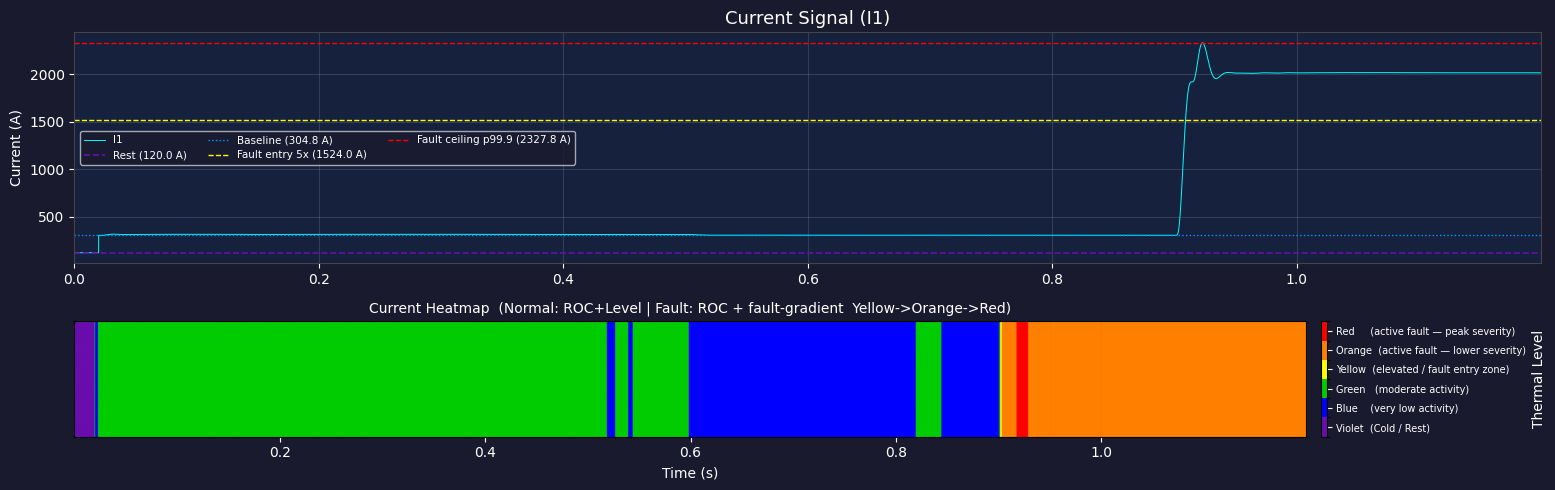

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5),
                                gridspec_kw={"height_ratios": [2, 1]})
fig.patch.set_facecolor("#1a1a2e")
for ax in (ax1, ax2): ax.set_facecolor("#16213e")

ax1.plot(time, current, color="cyan", linewidth=0.7, label="I1")
ax1.axhline(REST_VALUE,   color="#6A0DAD", linestyle="--", lw=1.2,
            label=f"Rest ({REST_VALUE} A)")
ax1.axhline(normal_I,     color="#0099ff", linestyle=":",  lw=1.0,
            label=f"Baseline ({round(normal_I,1)} A)")
ax1.axhline(thr_5x,       color="yellow",  linestyle="--", lw=1.0,
            label=f"Fault entry 5x ({round(thr_5x,1)} A)")
ax1.axhline(fault_ceiling, color="red",    linestyle="--", lw=1.0,
            label=f"Fault ceiling p99.9 ({round(fault_ceiling,1)} A)")
ax1.set_title("Current Signal (I1)", color="white", fontsize=13)
ax1.set_ylabel("Current (A)", color="white")
ax1.set_xlim(time[0], time[-1])
ax1.tick_params(colors="white"); ax1.spines[:].set_edgecolor("#444")
ax1.legend(fontsize=7.5, facecolor="#1a1a2e", labelcolor="white", ncol=3)
ax1.grid(True, alpha=0.2)

im = ax2.imshow(np.tile(color_index_I, (HEIGHT, 1)), cmap=cmap_thermal, norm=norm,
                aspect="auto", extent=[t_axis[0], t_axis[-1], 0, HEIGHT])
cbar = fig.colorbar(im, ax=ax2, ticks=[0,1,2,3,4,5], pad=0.01)
cbar.ax.set_yticklabels(COLOR_LABELS, fontsize=7)
cbar.set_label("Thermal Level", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
ax2.set_title(
    "Current Heatmap  (Normal: ROC+Level | Fault: ROC + fault-gradient  Yellow->Orange->Red)",
    color="white", fontsize=10)
ax2.set_xlabel("Time (s)", color="white")
ax2.set_yticks([]); ax2.tick_params(colors="white")
plt.tight_layout()
plt.show()

## CELL 7 — Voltage Signal + Heatmap (ROC-only)

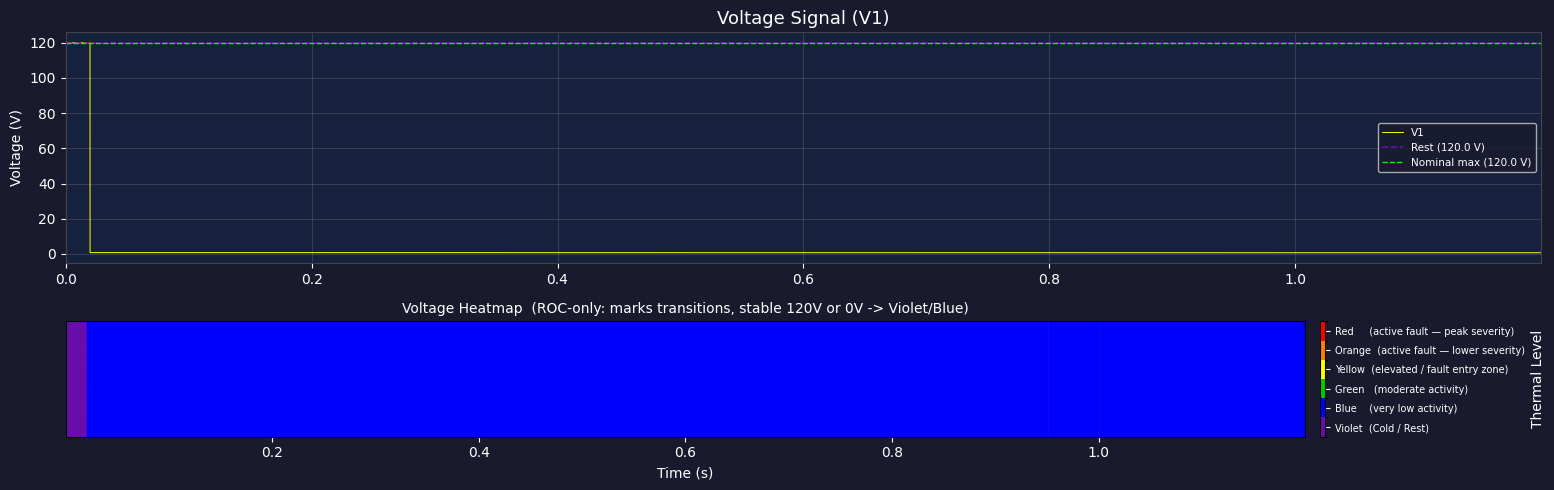

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5),
                                gridspec_kw={"height_ratios": [2, 1]})
fig.patch.set_facecolor("#1a1a2e")
for ax in (ax1, ax2): ax.set_facecolor("#16213e")

ax1.plot(time, voltage, color="yellow", linewidth=0.7, label="V1")
ax1.axhline(REST_VALUE, color="#6A0DAD", linestyle="--", lw=1.2,
            label=f"Rest ({REST_VALUE} V)")
ax1.axhline(v_nominal,  color="lime",    linestyle="--", lw=1.0,
            label=f"Nominal max ({round(v_nominal,1)} V)")
ax1.set_title("Voltage Signal (V1)", color="white", fontsize=13)
ax1.set_ylabel("Voltage (V)", color="white")
ax1.set_xlim(time[0], time[-1])
ax1.tick_params(colors="white"); ax1.spines[:].set_edgecolor("#444")
ax1.legend(fontsize=7.5, facecolor="#1a1a2e", labelcolor="white")
ax1.grid(True, alpha=0.2)

im = ax2.imshow(np.tile(color_index_V, (HEIGHT, 1)), cmap=cmap_thermal, norm=norm,
                aspect="auto", extent=[t_axis[0], t_axis[-1], 0, HEIGHT])
cbar = fig.colorbar(im, ax=ax2, ticks=[0,1,2,3,4,5], pad=0.01)
cbar.ax.set_yticklabels(COLOR_LABELS, fontsize=7)
cbar.set_label("Thermal Level", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
ax2.set_title(
    "Voltage Heatmap  (ROC-only: marks transitions, stable 120V or 0V -> Violet/Blue)",
    color="white", fontsize=10)
ax2.set_xlabel("Time (s)", color="white")
ax2.set_yticks([]); ax2.tick_params(colors="white")
plt.tight_layout()
plt.show()

## CELL 8 — Fused Heatmap

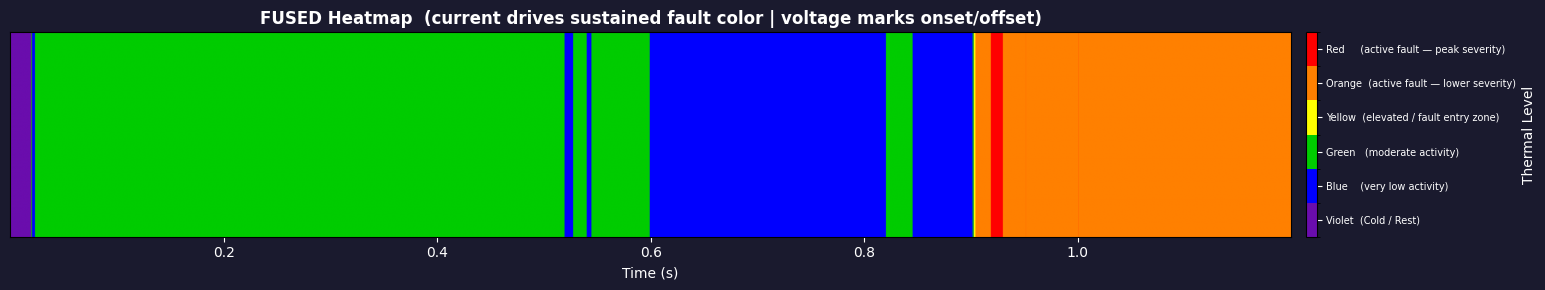

In [ ]:
fig, ax = plt.subplots(figsize=(16, 3))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#16213e")

im = ax.imshow(np.tile(color_index_fused, (HEIGHT, 1)), cmap=cmap_thermal, norm=norm,
               aspect="auto", extent=[t_axis[0], t_axis[-1], 0, HEIGHT])
cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2,3,4,5], pad=0.01)
cbar.ax.set_yticklabels(COLOR_LABELS, fontsize=7)
cbar.set_label("Thermal Level", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
ax.set_title(
    "FUSED Heatmap  (current drives sustained fault color | voltage marks onset/offset)",
    color="white", fontsize=12, fontweight="bold")
ax.set_xlabel("Time (s)", color="white")
ax.set_yticks([]); ax.tick_params(colors="white")
plt.tight_layout()
plt.show()

## CELL 9 — Color Percentage Breakdown

In [ ]:
total   = len(color_index_fused)
percent = {
    "V": np.sum(color_index_fused == 0) / total * 100,
    "B": np.sum(color_index_fused == 1) / total * 100,
    "G": np.sum(color_index_fused == 2) / total * 100,
    "Y": np.sum(color_index_fused == 3) / total * 100,
    "O": np.sum(color_index_fused == 4) / total * 100,
    "R": np.sum(color_index_fused == 5) / total * 100,
}

print("Fused Color Distribution:")
print("-" * 62)
for key, label in zip("VBGYOR", COLOR_LABELS):
    bar = "#" * int(percent[key] / 1.5)
    print(f"  {label:<46} {percent[key]:6.2f}%  {bar}")

COLD    = percent["V"]
NORMAL  = percent["B"] + percent["G"]
WARNING = percent["Y"] + percent["O"]
DANGER  = percent["R"]

print()
print(f"  COLD     (Violet)            : {COLD:6.2f}%")
print(f"  NORMAL   (Blue + Green)      : {NORMAL:6.2f}%")
print(f"  WARNING  (Yellow + Orange)   : {WARNING:6.2f}%")
print(f"  DANGER   (Red)               : {DANGER:6.2f}%")

Fused Color Distribution:
--------------------------------------------------------------
  Violet  (Cold / Rest)                            1.66%  #
  Blue    (very low activity)                     24.38%  ################
  Green   (moderate activity)                     49.13%  ################################
  Yellow  (elevated / fault entry zone)            0.12%  
  Orange  (active fault — lower severity)         23.75%  ###############
  Red     (active fault — peak severity)           0.95%  

  COLD     (Violet)            :   1.66%
  NORMAL   (Blue + Green)      :  73.51%
  WARNING  (Yellow + Orange)   :  23.87%
  DANGER   (Red)               :   0.95%


## CELL 10 — NVA Score

In [ ]:
weights = {"V": 0.0, "B": 0.2, "G": 0.3, "Y": 0.6, "O": 0.8, "R": 1.0}
NVA     = sum((percent[k] / 100) * weights[k] for k in percent)

if   NVA <= 0.2: state = "GOOD"
elif NVA <= 0.4: state = "OK"
elif NVA <= 0.6: state = "AVERAGE"
elif NVA <= 0.8: state = "FAULTY"
else:            state = "SEVERE FAULT"

print(f"NVA Score    : {round(NVA, 4)}   (0.0 = perfect  /  1.0 = total fault)")
print(f"System State : {state}")
print()
print("  Scale: 0.00-0.20 GOOD | 0.20-0.40 OK | 0.40-0.60 AVERAGE")
print("         0.60-0.80 FAULTY | >0.80 SEVERE FAULT")

NVA Score    : 0.3964   (0.0 = perfect  /  1.0 = total fault)
System State : OK

  Scale: 0.00-0.20 GOOD | 0.20-0.40 OK | 0.40-0.60 AVERAGE
         0.60-0.80 FAULTY | >0.80 SEVERE FAULT


## CELL 11 — Binary Output (1 = dominant state)

In [ ]:
b_cold    = "1" if COLD    >= 50 else "0"
b_normal  = "1" if NORMAL  >= 25 else "0"
b_warning = "1" if WARNING >= 15 else "0"
b_danger  = "1" if DANGER  >= 10 else "0"

binary = b_cold + b_normal + b_warning + b_danger

interp_map = {

    # ── NO BIT DOMINANT ───────────────────────────────────────────────────────
    "0000": "Transitional state — no zone exceeds its threshold, signal is ambiguous",

    # ── SINGLE BIT ────────────────────────────────────────────────────────────
    "1000": "Machine was idle for majority of recording — at rest, no fault activity",
    "0100": "Healthy normal operation was the dominant phase of recording",
    "0010": "Pre-fault warning stress was the dominant phase — no confirmed fault yet",
    "0001": "Active fault was the dominant phase — severe fault condition confirmed",

    # ── TWO BITS ──────────────────────────────────────────────────────────────
    "1100": "Machine startup or shutdown — idle transitioning into or out of normal operation",
    "1010": "Idle machine with notable stress bursts — rest broken by pre-fault activity",
    "1001": "Idle machine with confirmed fault events — cold interrupted by active fault",
    "0110": "Normal operation climbing into warning zone — load increasing toward fault threshold",
    "0101": "Normal operation with confirmed fault bursts — isolated fault in otherwise healthy run",
    "0011": "Warning actively escalating into fault — fault arrival captured in this recording",

    # ── THREE BITS ────────────────────────────────────────────────────────────
    "1110": "Machine startup/shutdown with pre-fault stress — normal operation not fully established",
    "1101": "Machine startup/shutdown interrupted by fault — fault occurred during transition",
    "1011": "Idle-dominant recording with both warning and fault activity — cold with fault bursts",
    "0111": "Full fault lifecycle captured — normal, warning and active fault all present",

    # ── ALL FOUR ──────────────────────────────────────────────────────────────
    "1111": "Cold start but still got a fault!",
}

print(f"Binary Output : {binary}   [ COLD | NORMAL | WARNING | DANGER ]")
print(f"  Bit 3 COLD    = {b_cold}   ({COLD:5.2f}%)")
print(f"  Bit 2 NORMAL  = {b_normal}   ({NORMAL:5.2f}%)")
print(f"  Bit 1 WARNING = {b_warning}   ({WARNING:5.2f}%)")
print(f"  Bit 0 DANGER  = {b_danger}   ({DANGER:5.2f}%)")
print()
print(f"Interpretation : {interp_map.get(binary, 'Mixed state — see percentages above')}")

Binary Output : 0110   [ COLD | NORMAL | WARNING | DANGER ]
  Bit 3 COLD    = 0   ( 1.66%)
  Bit 2 NORMAL  = 1   (73.51%)
  Bit 1 WARNING = 1   (23.87%)
  Bit 0 DANGER  = 0   ( 0.95%)

Interpretation : Normal operation climbing into warning zone — load increasing toward fault threshold
